# Final results

In [ ]:
import sys
sys.path.append("../src")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from energy_load_forecast.config import get_entsoe_api_key
from energy_load_forecast.ingestion import load_and_resample_api, save_raw
from energy_load_forecast.preprocessing import clean_tail, add_calendar_features, chronological_split
from energy_load_forecast.features import add_all_features
from energy_load_forecast.models.baselines import naive_forecast, seasonal_naive_forecast
from energy_load_forecast.models.lightgbm_model import (
    train_lightgbm,
    feature_importance,
    train_quantile_models,
)
from energy_load_forecast.models.nbeats_model import train_nbeats, predict as nbeats_predict
from energy_load_forecast.evaluation import evaluate
from energy_load_forecast.interval_evaluation import coverage, interval_width, pinball_loss


In [ ]:
country_code = "RO"
start = pd.Timestamp("2025-07-01", tz="UTC")
end = pd.Timestamp("2026-01-01", tz="UTC")

cache_path = Path(
    f"../data/raw/entsoe/load_{country_code}_api_{start.date()}_{end.date()}.csv"
)

series = None
if cache_path.exists():
    cached = pd.read_csv(cache_path, index_col="timestamp_utc")
    cached.index = pd.to_datetime(cached.index, utc=True)
    cached = cached["load_mw"].sort_index()

    deltas = cached.index.to_series().diff().dropna()
    is_hourly = bool(
        len(cached) > 0
        and (deltas.empty or deltas.eq(pd.Timedelta(hours=1)).all())
    )
    valid_cache = (
        is_hourly
        and not cached.index.has_duplicates
        and not cached.isna().all()
        and (cached.dropna() >= 0).all()
    )

    if valid_cache:
        series = cached
        print("Hourly cache found:", cache_path)
    else:
        print("Existing cache is invalid or not hourly; fetching a fresh series.")

if series is None:
    api_key = get_entsoe_api_key()
    series = load_and_resample_api(country_code, start, end, api_key=api_key)
    save_raw(series, cache_path)
    print("Saved hourly cache:", cache_path)

print("Raw hourly shape:", series.shape)
print("Range:", series.index.min(), "to", series.index.max())
print("Median spacing:", series.index.to_series().diff().dropna().median())


Hourly cache found: ..\data\raw\entsoe\load_RO_api_2025-07-01_2026-01-01.csv
Raw hourly shape: (4416,)
Range: 2025-07-01 00:00:00+00:00 to 2025-12-31 23:00:00+00:00
Median spacing: 0 days 01:00:00


In [ ]:
series_clean = clean_tail(series)

# Reserve one complete 24-hour validation window and one complete 24-hour test window.
test_start = series_clean.index[-24]
val_start = test_start - pd.Timedelta(hours=24)

base_df = add_calendar_features(series_clean.to_frame(name="load_mw"))
train_df, val_df, test_df = chronological_split(
    base_df,
    train_end=val_start,
    val_end=test_start,
)

print("Train range:", train_df.index.min(), "to", train_df.index.max())
print("Val range:  ", val_df.index.min(), "to", val_df.index.max())
print("Test range: ", test_df.index.min(), "to", test_df.index.max())
print("Sizes:", len(train_df), len(val_df), len(test_df))


Train range: 2025-07-01 00:00:00+00:00 to 2025-12-29 23:00:00+00:00
Val range:   2025-12-30 00:00:00+00:00 to 2025-12-30 23:00:00+00:00
Test range:  2025-12-31 00:00:00+00:00 to 2025-12-31 23:00:00+00:00
Sizes: 4368 24 24


In [ ]:
feature_df = add_all_features(
    base_df,
    lags=(1, 24, 168),
    windows=(3, 24),
)
feature_cols = [col for col in feature_df.columns if col != "load_mw"]

train_features = feature_df.loc[train_df.index].dropna(subset=feature_cols)
print("Training rows after removing insufficient-history features:", len(train_features))
print("Feature columns:", feature_cols)


Training rows after removing insufficient-history features: 4200
Feature columns: ['hour_local', 'day_of_week_local', 'is_weekend_local', 'month_local', 'load_mw_lag1', 'load_mw_lag24', 'load_mw_lag168', 'load_mw_rolling_mean_3h', 'load_mw_rolling_mean_24h']


In [ ]:
def recursive_lgbm_forecast(model, history, future_index, feature_columns):
    """Forecast each future hour using previous observations or predictions.

    This prevents actual validation/test load values from entering lag or
    rolling features during a multi-step forecast.
    """
    history = history.copy()
    predictions = []

    for timestamp in future_index:
        local = timestamp.tz_convert("Europe/Bucharest")
        row = {
            "hour_local": local.hour,
            "day_of_week_local": local.day_of_week,
            "is_weekend_local": local.day_of_week >= 5,
            "month_local": local.month,
            "load_mw_lag1": history.iloc[-1],
            "load_mw_lag24": history.iloc[-24],
            "load_mw_lag168": history.iloc[-168],
            "load_mw_rolling_mean_3h": history.iloc[-3:].mean(),
            "load_mw_rolling_mean_24h": history.iloc[-24:].mean(),
        }
        X_row = pd.DataFrame([row], index=[timestamp])[feature_columns]
        prediction = float(model.predict(X_row)[0])
        predictions.append(prediction)
        history.loc[timestamp] = prediction

    return pd.Series(predictions, index=future_index, name="forecast")


In [ ]:
# --- Validation baselines ---
train_history = series_clean.loc[series_clean.index < val_start]
y_val = series_clean.loc[val_start:test_start - pd.Timedelta(hours=1)]

val_naive = naive_forecast(train_history, horizon=24)
val_seasonal = seasonal_naive_forecast(train_history, horizon=24, season_length=24)

val_metrics = pd.DataFrame(
    [
        evaluate(y_val, val_naive),
        evaluate(y_val, val_seasonal),
    ],
    index=["Naive", "Seasonal Naive"],
)
print("Validation baseline metrics:\n", val_metrics)


Validation baseline metrics:
                         MAE         RMSE       MAPE
Naive           1055.281250  1280.287300  14.908679
Seasonal Naive   205.510417   244.489205   3.145424


In [ ]:
# --- LightGBM validation ---
model_val_lgbm = train_lightgbm(
    train_features.drop(columns=["load_mw"]),
    train_features["load_mw"],
)

val_lgbm = recursive_lgbm_forecast(
    model_val_lgbm,
    train_history,
    y_val.index,
    feature_cols,
)
val_metrics.loc["LightGBM"] = evaluate(y_val, val_lgbm)
print("Validation metrics:\n", val_metrics)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000129 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1315
[LightGBM] [Info] Number of data points in the train set: 4200, number of used features: 9
[LightGBM] [Info] Start training from score 6093.424137
Validation metrics:
                         MAE         RMSE       MAPE
Naive           1055.281250  1280.287300  14.908679
Seasonal Naive   205.510417   244.489205   3.145424
LightGBM         214.743774   251.323670   3.245073


In [ ]:
# --- Final LightGBM fit on train + validation ---
train_val_features = feature_df.loc[feature_df.index < test_start].dropna(subset=feature_cols)
model_lgbm = train_lightgbm(
    train_val_features.drop(columns=["load_mw"]),
    train_val_features["load_mw"],
)

history_test = series_clean.loc[series_clean.index < test_start]
y_test = series_clean.loc[test_start:]

naive_test = naive_forecast(history_test, horizon=24)
seasonal_test = seasonal_naive_forecast(history_test, horizon=24, season_length=24)
lgbm_test = recursive_lgbm_forecast(
    model_lgbm,
    history_test,
    y_test.index,
    feature_cols,
)

metrics_naive = evaluate(y_test, naive_test)
metrics_seasonal = evaluate(y_test, seasonal_test)
metrics_lgbm = evaluate(y_test, lgbm_test)

print("Test metrics:")
print(metrics_naive)
print(metrics_seasonal)
print(metrics_lgbm)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000054 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1315
[LightGBM] [Info] Number of data points in the train set: 4224, number of used features: 9
[LightGBM] [Info] Start training from score 6096.340702
Test metrics:
{'MAE': 773.2395833333334, 'RMSE': 975.4298157842179, 'MAPE': 11.270437186973469}
{'MAE': 199.375, 'RMSE': 256.48360287095676, 'MAPE': 3.029829839891998}
{'MAE': 230.05206806376472, 'RMSE': 266.8211412202465, 'MAPE': 3.645658178470041}


In [ ]:
# --- P10-P90 LightGBM interval ---
quantile_models = train_quantile_models(
    train_val_features.drop(columns=["load_mw"]),
    train_val_features["load_mw"],
    alphas=(0.1, 0.5, 0.9),
)

q10 = recursive_lgbm_forecast(
    quantile_models[0.1], history_test, y_test.index, feature_cols
)
q90 = recursive_lgbm_forecast(
    quantile_models[0.9], history_test, y_test.index, feature_cols
)
lower = pd.Series(
    np.minimum(q10.to_numpy(), q90.to_numpy()), index=y_test.index, name="q10"
)
upper = pd.Series(
    np.maximum(q10.to_numpy(), q90.to_numpy()), index=y_test.index, name="q90"
)

interval_results = {
    "P10_pinball": pinball_loss(y_test, q10, 0.1),
    "P90_pinball": pinball_loss(y_test, q90, 0.9),
    "coverage_pct": coverage(y_test, lower, upper),
    "mean_width_mw": interval_width(lower, upper),
}
print("P10-P90 interval metrics:", interval_results)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000056 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1315
[LightGBM] [Info] Number of data points in the train set: 4224, number of used features: 9
[LightGBM] [Info] Start training from score 4937.299805
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000054 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1315
[LightGBM] [Info] Number of data points in the train set: 4224, number of used features: 9
[LightGBM] [Info] Start training from score 5973.500000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000053 seconds.
You can

In [ ]:
# --- N-BEATS ---
nbeats_model_val, scaler_val, train_scaled_val = train_nbeats(
    train_history,
    input_chunk_length=24,
    output_chunk_length=24,
    n_epochs=20,
    use_gpu=False,
)
val_nbeats = nbeats_predict(
    nbeats_model_val,
    scaler_val,
    train_scaled_val,
    horizon=24,
    target_index=y_val.index,
)
val_metrics.loc["N-BEATS"] = evaluate(y_val, val_nbeats)
print("Validation metrics including N-BEATS:\n", val_metrics)

nbeats_model, scaler, train_scaled = train_nbeats(
    history_test,
    input_chunk_length=24,
    output_chunk_length=24,
    n_epochs=20,
    use_gpu=False,
)
nbeats_test = nbeats_predict(
    nbeats_model,
    scaler,
    train_scaled,
    horizon=24,
    target_index=y_test.index,
)
metrics_nbeats = evaluate(y_test, nbeats_test)
print("N-BEATS test metrics:", metrics_nbeats)


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
c:\Users\Gabriel\Desktop\Projects\energy_load_forecast\.venv\Lib\site-packages\pytorch_lightning\trainer\setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\Gabriel\Desktop\Projects\energy_load_forecast\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Gabriel\Desktop\Projects\energy_load_forecast\.venv\Lib\site-packages\pytorch_lightning\utilities\data.py:106: Total length of `list` across ranks is zero. Please make sure this was your intention.
`Trainer.fit` stopped: `max_epochs=20` rea

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 64.92it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
c:\Users\Gabriel\Desktop\Projects\energy_load_forecast\.venv\Lib\site-packages\pytorch_lightning\trainer\setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\Gabriel\Desktop\Projects\energy_load_forecast\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Gabriel\Desktop\Projects\energy_load_forecast\.venv\Lib\site-packages\pytorch_lightning\utilities\data.py:106: Total length of `list` across ranks is zero. Please make sure this was your intention.



Validation metrics including N-BEATS:
                         MAE         RMSE       MAPE
Naive           1055.281250  1280.287300  14.908679
Seasonal Naive   205.510417   244.489205   3.145424
LightGBM         214.743774   251.323670   3.245073
N-BEATS          235.362585   282.708817   3.638203


`Trainer.fit` stopped: `max_epochs=20` reached.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 62.23it/s]
N-BEATS test metrics: {'MAE': 300.97107303974514, 'RMSE': 352.9764836279705, 'MAPE': 4.732125221332554}


In [ ]:
results = {
    "Naive": metrics_naive,
    "Seasonal Naive": metrics_seasonal,
    "LightGBM": metrics_lgbm,
    "N-BEATS": metrics_nbeats,
}
comparison = pd.DataFrame(results).T
print("\nFinal 24-hour test comparison:")
print(comparison)

Path("../docs").mkdir(exist_ok=True)
with open("../docs/results.md", "w", encoding="utf-8") as f:
    f.write(
        f"Dataset: {country_code}, {start.date()} to {end.date()}\n"
        f"Final horizon: 24 hours\n"
        f"Validation start: {val_start}\n"
        f"Test start: {test_start}\n\n"
    )
    f.write(comparison.to_markdown())
    f.write("\n\nP10-P90 interval metrics:\n")
    f.write(pd.DataFrame([interval_results]).to_markdown(index=False))

print("Saved docs/results.md")



Final 24-hour test comparison:
                       MAE        RMSE       MAPE
Naive           773.239583  975.429816  11.270437
Seasonal Naive  199.375000  256.483603   3.029830
LightGBM        230.052068  266.821141   3.645658
N-BEATS         300.971073  352.976484   4.732125
Saved docs/results.md


Saved docs/all_models_comparison_plot.png


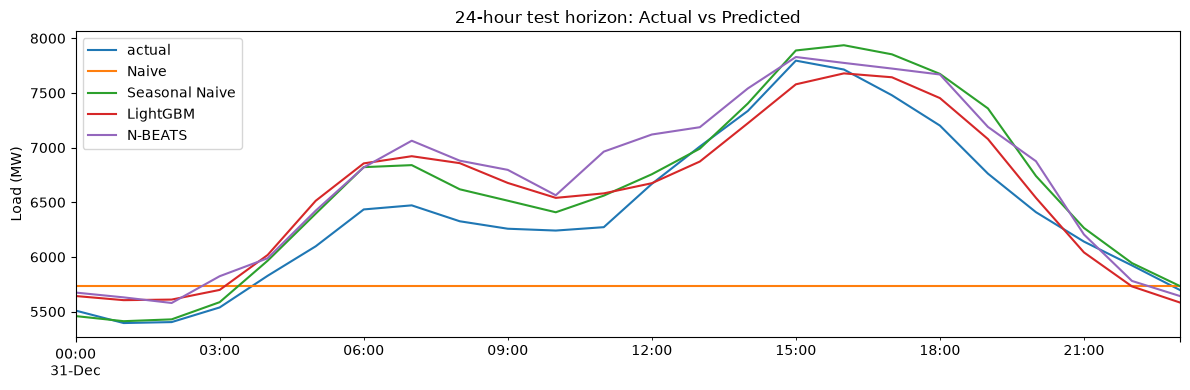

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
all_preds = pd.DataFrame(
    {
        "actual": y_test,
        "Naive": naive_test,
        "Seasonal Naive": seasonal_test,
        "LightGBM": lgbm_test,
        "N-BEATS": nbeats_test,
    }
)
all_preds.plot(ax=ax, title="24-hour test horizon: Actual vs Predicted")
ax.set_ylabel("Load (MW)")
fig.tight_layout()
fig.savefig("../docs/all_models_comparison_plot.png", dpi=150, bbox_inches="tight")
print("Saved docs/all_models_comparison_plot.png")


Feature importances:
 hour_local                  692
load_mw_lag1                627
load_mw_lag168              399
load_mw_rolling_mean_3h     394
load_mw_rolling_mean_24h    293
load_mw_lag24               250
month_local                 212
day_of_week_local           133
is_weekend_local              0
dtype: int32
Saved final plots to docs/


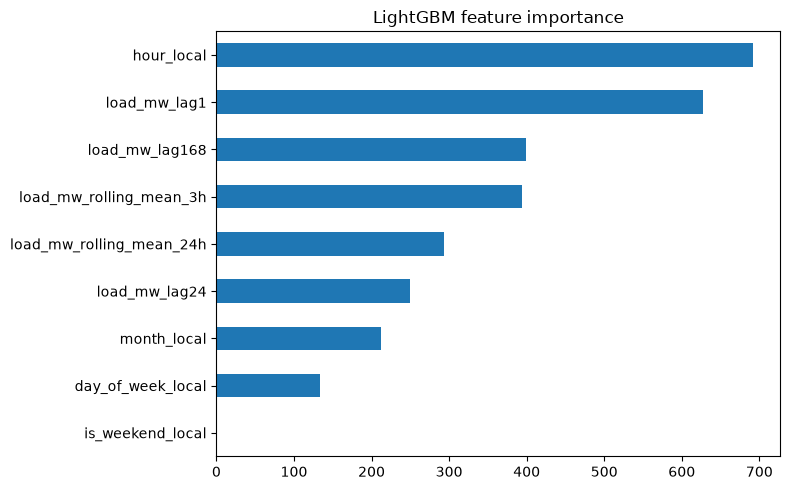

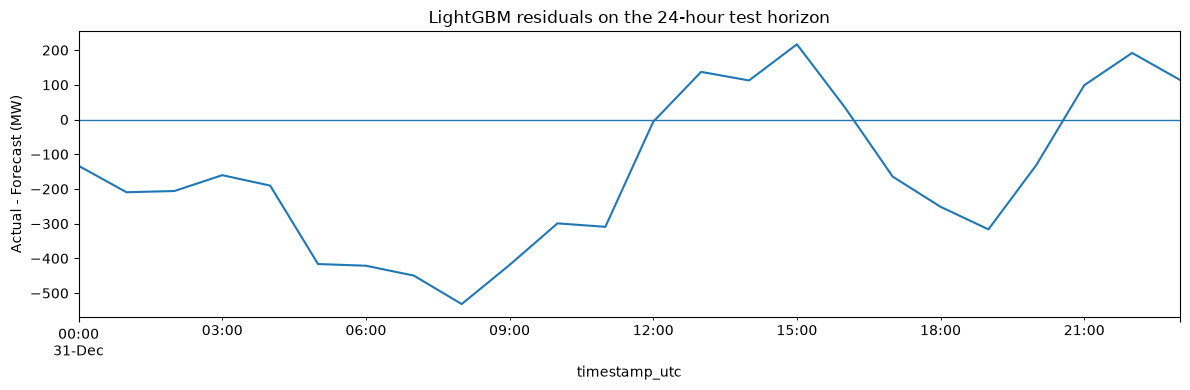

In [ ]:
importances = feature_importance(model_lgbm, feature_cols)
print("Feature importances:\n", importances)

fig, ax = plt.subplots(figsize=(8, 5))
importances.sort_values().plot(kind="barh", ax=ax, title="LightGBM feature importance")
fig.tight_layout()
fig.savefig("../docs/lightgbm_feature_importance.png", dpi=150, bbox_inches="tight")

residuals = y_test - lgbm_test
fig2, ax2 = plt.subplots(figsize=(12, 4))
residuals.plot(ax=ax2, title="LightGBM residuals on the 24-hour test horizon")
ax2.axhline(0, linewidth=1)
ax2.set_ylabel("Actual - Forecast (MW)")
fig2.tight_layout()
fig2.savefig("../docs/lightgbm_residuals.png", dpi=150, bbox_inches="tight")

print("Saved final plots to docs/")
